In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
from sklearn.model_selection import KFold

from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler

In [162]:
train_df=pd.read_csv("./playground-series-s5e5/train.csv")
test_df=pd.read_csv("./playground-series-s5e5/test.csv")

In [163]:
test_ids=test_df['id']

In [164]:
numerical_features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

In [165]:
train=train_df.copy()
test=test_df.copy()

In [166]:
def add_feature_cross_terms(df, features):
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()]  
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            f1 = features[i]
            f2 = features[j]
            df[f"{f1}_x_{f2}"] = df[f1] * df[f2]
    return df

def add_interaction_features(df, features):
    df_new = df.copy()
    for f1, f2 in itertools.combinations(features, 2):
        df_new[f"{f1}_plus_{f2}"] = df_new[f1] + df_new[f2]
        df_new[f"{f1}_minus_{f2}"] = df_new[f1] - df_new[f2]
        df_new[f"{f2}_minus_{f1}"] = df_new[f2] - df_new[f1]
        df_new[f"{f1}_div_{f2}"] = df_new[f1] / (df_new[f2] + 1e-5)
        df_new[f"{f2}_div_{f1}"] = df_new[f2] / (df_new[f1] + 1e-5)
    return df_new

def add_statistical_features(df, features):
    df_new = df.copy()
    df_new["row_mean"] = df[features].mean(axis=1)
    df_new["row_std"] = df[features].std(axis=1)
    df_new["row_max"] = df[features].max(axis=1)
    df_new["row_min"] = df[features].min(axis=1)
    df_new["row_median"] = df[features].median(axis=1)
    return df_new

train = add_feature_cross_terms(train, numerical_features)
test = add_feature_cross_terms(test, numerical_features)

train = add_interaction_features(train, numerical_features)
test = add_interaction_features(test, numerical_features)

train = add_statistical_features(train, numerical_features)
test = add_statistical_features(test, numerical_features)

le = LabelEncoder()
train['Sex'] = le.fit_transform(train['Sex'])
test['Sex'] = le.transform(test['Sex'])

train['Sex'] = train['Sex'].astype('category')
test['Sex'] = test['Sex'].astype('category')

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly_train = poly.fit_transform(train[numerical_features])
poly_test = poly.transform(test[numerical_features])
poly_feature_names = poly.get_feature_names_out(numerical_features)

poly_train_df = pd.DataFrame(poly_train, columns=poly_feature_names)
poly_test_df = pd.DataFrame(poly_test, columns=poly_feature_names)

train = pd.concat([train.reset_index(drop=True), poly_train_df], axis=1)
test = pd.concat([test.reset_index(drop=True), poly_test_df], axis=1)

X = train.drop(columns=['id', 'Calories'])
y = np.log1p(train['Calories'])  
X_test = test.drop(columns=['id'])


FEATURES = X.columns.tolist()

In [167]:
print("Train shape:", train.shape)
train.head()

Train shape: (750000, 125)


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Age_x_Height,...,Height Weight,Height Duration,Height Heart_Rate,Height Body_Temp,Weight Duration,Weight Heart_Rate,Weight Body_Temp,Duration Heart_Rate,Duration Body_Temp,Heart_Rate Body_Temp
0,0,1,36,189.0,82.0,26.0,101.0,41.0,150.0,6804.0,...,15498.0,4914.0,19089.0,7749.0,2132.0,8282.0,3362.0,2626.0,1066.0,4141.0
1,1,0,64,163.0,60.0,8.0,85.0,39.7,34.0,10432.0,...,9780.0,1304.0,13855.0,6471.1,480.0,5100.0,2382.0,680.0,317.6,3374.5
2,2,0,51,161.0,64.0,7.0,84.0,39.8,29.0,8211.0,...,10304.0,1127.0,13524.0,6407.8,448.0,5376.0,2547.2,588.0,278.6,3343.2
3,3,1,20,192.0,90.0,25.0,105.0,40.7,140.0,3840.0,...,17280.0,4800.0,20160.0,7814.4,2250.0,9450.0,3663.0,2625.0,1017.5,4273.5
4,4,0,38,166.0,61.0,25.0,102.0,40.6,146.0,6308.0,...,10126.0,4150.0,16932.0,6739.6,1525.0,6222.0,2476.6,2550.0,1015.0,4141.2


In [168]:
print("Test shape:", train.shape)
test.head()

Test shape: (750000, 125)


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Age_x_Height,Age_x_Weight,...,Height Weight,Height Duration,Height Heart_Rate,Height Body_Temp,Weight Duration,Weight Heart_Rate,Weight Body_Temp,Duration Heart_Rate,Duration Body_Temp,Heart_Rate Body_Temp
0,750000,1,45,177.0,81.0,7.0,87.0,39.8,7965.0,3645.0,...,14337.0,1239.0,15399.0,7044.6,567.0,7047.0,3223.8,609.0,278.6,3462.6
1,750001,1,26,200.0,97.0,20.0,101.0,40.5,5200.0,2522.0,...,19400.0,4000.0,20200.0,8100.0,1940.0,9797.0,3928.5,2020.0,810.0,4090.5
2,750002,0,29,188.0,85.0,16.0,102.0,40.4,5452.0,2465.0,...,15980.0,3008.0,19176.0,7595.2,1360.0,8670.0,3434.0,1632.0,646.4,4120.8
3,750003,0,39,172.0,73.0,20.0,107.0,40.6,6708.0,2847.0,...,12556.0,3440.0,18404.0,6983.2,1460.0,7811.0,2963.8,2140.0,812.0,4344.2
4,750004,0,30,173.0,67.0,16.0,94.0,40.5,5190.0,2010.0,...,11591.0,2768.0,16262.0,7006.5,1072.0,6298.0,2713.5,1504.0,648.0,3807.0


In [169]:
X=train.drop(columns=['Calories'])
y=train['Calories']

In [170]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Columns: 124 entries, id to Heart_Rate Body_Temp
dtypes: category(1), float64(121), int64(2)
memory usage: 704.5 MB


In [171]:
xgb_model=XGBRegressor(enable_categorical=True)

In [172]:
print(type(X))

<class 'pandas.core.frame.DataFrame'>


In [173]:
xgb_model.fit(X.to_numpy(), y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

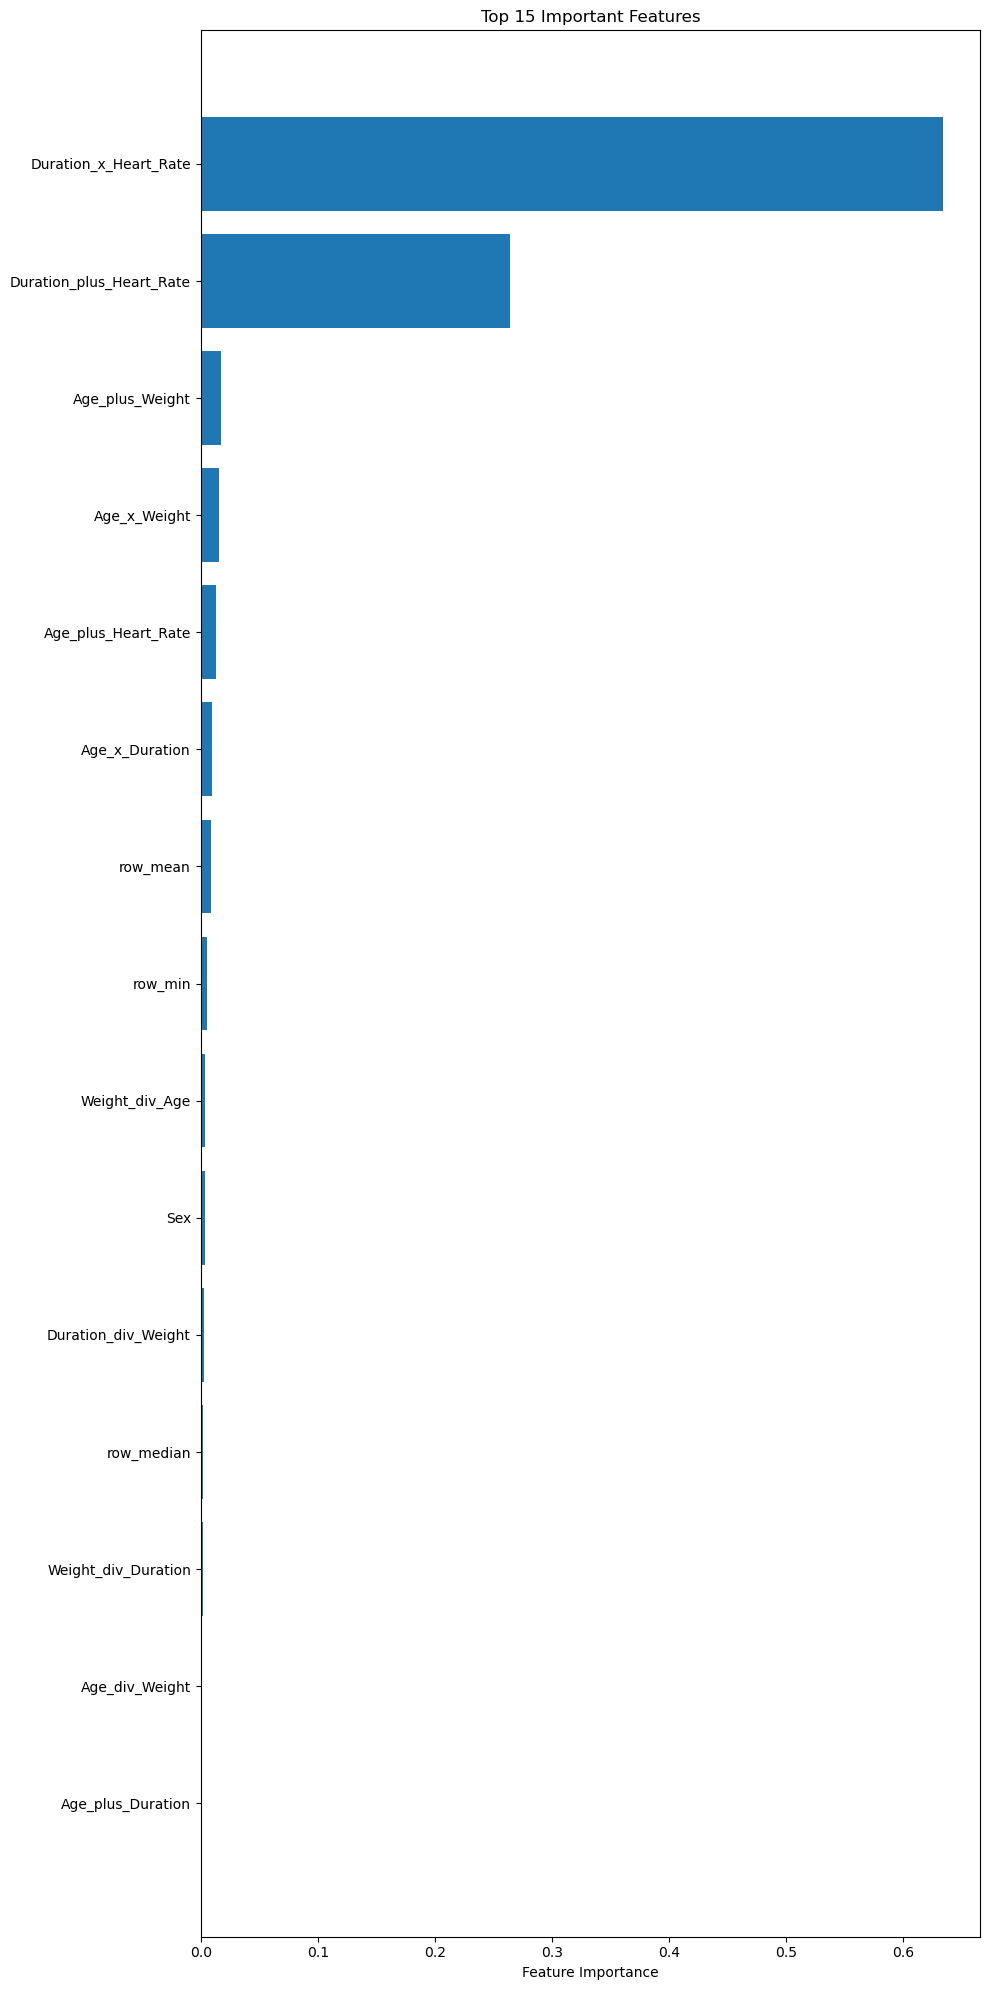

In [174]:
importances = xgb_model.feature_importances_
features = X.columns

# Sort in descending order
indices = np.argsort(importances)[::-1]
sorted_features = features[indices]
sorted_importances = importances[indices]

# Plot (top 40 shown for better readability)
plt.figure(figsize=(10, 20))  # Adjust size (width, height)
plt.barh(sorted_features[:15][::-1], sorted_importances[:15][::-1])  # Reverse for top-down
plt.xlabel("Feature Importance")
plt.title("Top 15 Important Features")
plt.tight_layout()
plt.show()

In [175]:
cat_model=CatBoostRegressor(verbose=0)

In [176]:
cat_model.fit(X.to_numpy(), y)

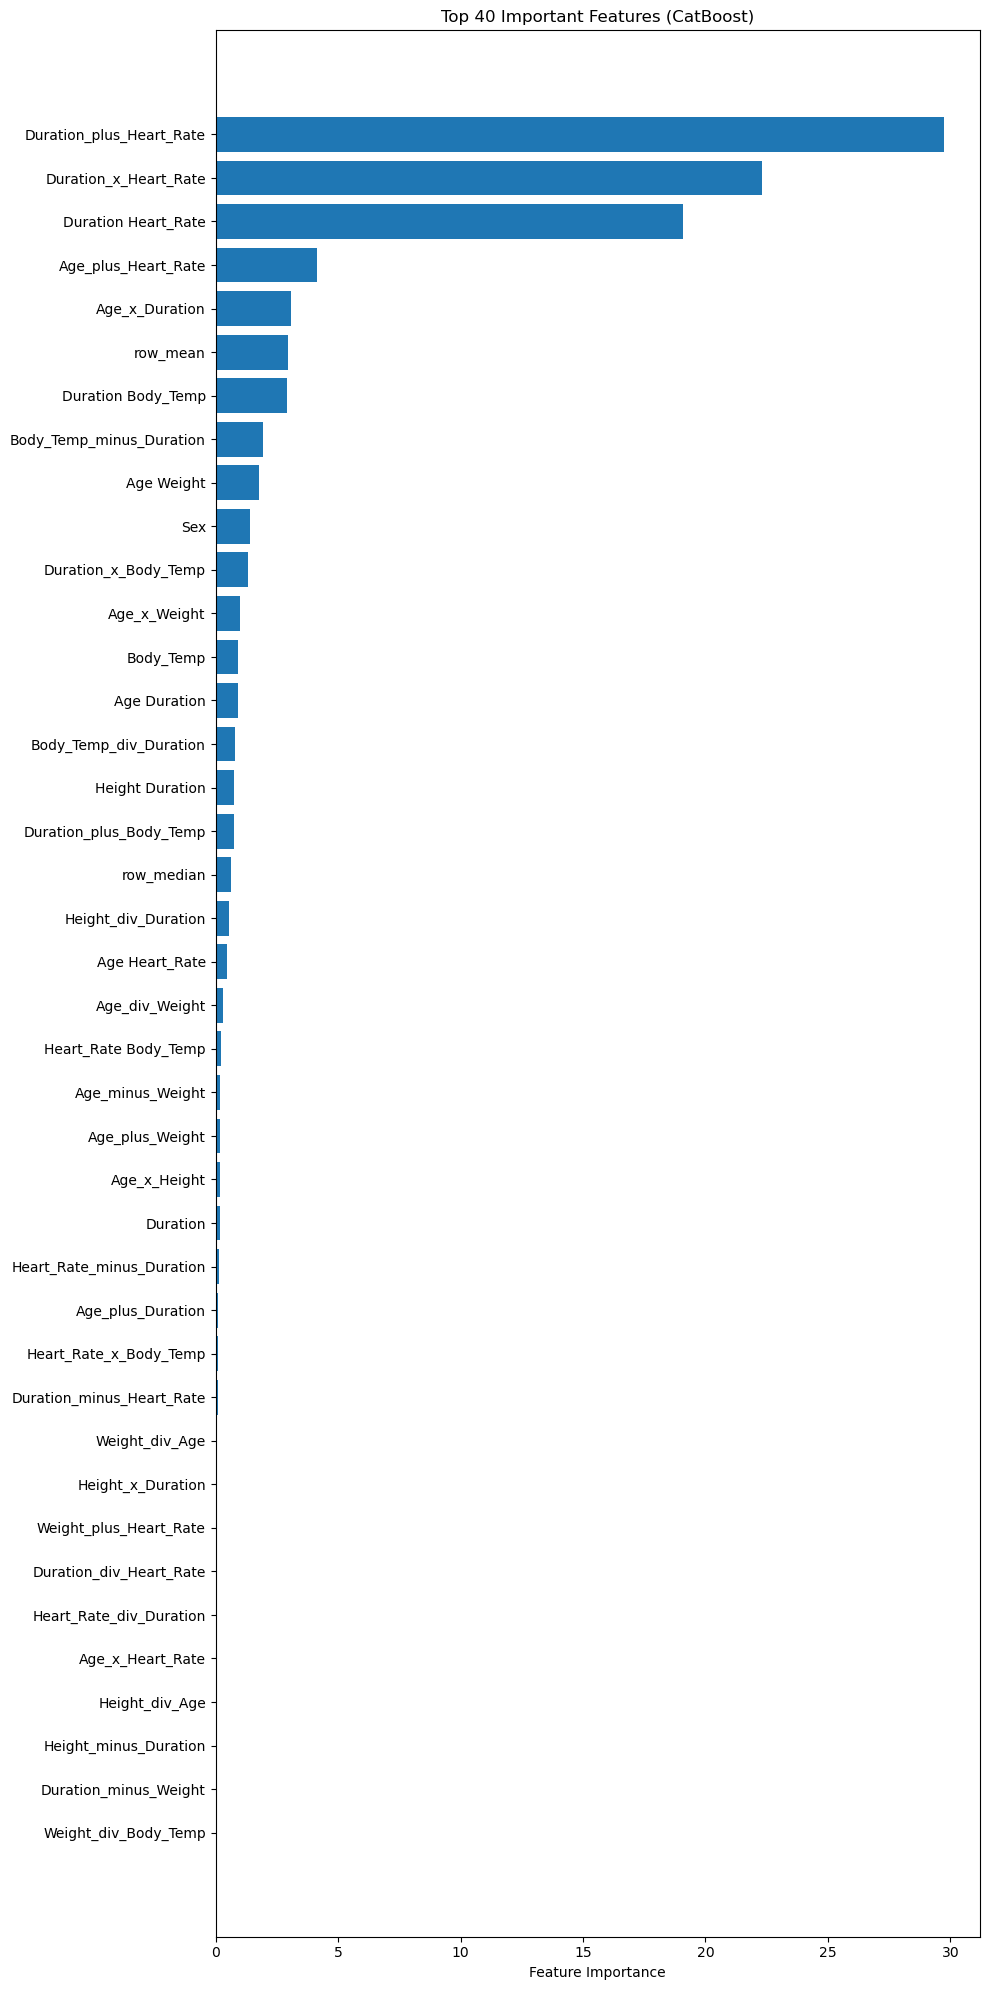

In [177]:
importances = cat_model.get_feature_importance()
feature_names = X.columns

# Create a DataFrame for easy sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 40
plt.figure(figsize=(10, 20))
plt.barh(importance_df['Feature'][:40][::-1], importance_df['Importance'][:40][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 40 Important Features (CatBoost)")
plt.tight_layout()
plt.show()

In [178]:
lgb_model=LGBMRegressor()

In [179]:
lgb_model.fit(X.to_numpy(), y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23841
[LightGBM] [Info] Number of data points in the train set: 750000, number of used features: 124
[LightGBM] [Info] Start training from score 88.282781


LGBMRegressor()

In [180]:
xgb_importance = xgb_model.feature_importances_
cat_importance = cat_model.get_feature_importance()
lgb_importance = lgb_model.feature_importances_

df = pd.DataFrame({
    'feature': X.columns,
    'xgb': xgb_importance,
    'cat': cat_importance,
    'lgb': lgb_importance
})

# Normalize importance (optional but helpful)
for col in ['xgb', 'cat', 'lgb']:
    df[col] = df[col] / df[col].max()

# Calculate average importance or rank
df['avg_importance'] = df[['xgb', 'cat', 'lgb']].mean(axis=1)
# Or use: df['avg_rank'] = df[['xgb', 'cat', 'lgb']].rank(ascending=False).mean(axis=1)

# Sort and get top features
top_features = df.sort_values(by='avg_importance', ascending=False)['feature'][:100].tolist()
print(top_features)

['Duration_x_Heart_Rate', 'Duration_plus_Heart_Rate', 'Sex', 'Duration_minus_Heart_Rate', 'Age_plus_Heart_Rate', 'Duration Heart_Rate', 'Age_x_Duration', 'row_mean', 'Age_plus_Weight', 'Age_x_Weight', 'row_median', 'Weight_minus_Duration', 'Body_Temp', 'Duration_div_Heart_Rate', 'Heart_Rate_x_Body_Temp', 'Duration_div_Weight', 'Age_div_Weight', 'Heart_Rate_minus_Duration', 'Weight_div_Duration', 'Age_plus_Duration', 'Heart_Rate_div_Duration', 'Age_minus_Heart_Rate', 'Heart_Rate_div_Body_Temp', 'row_min', 'Age_x_Heart_Rate', 'Duration Body_Temp', 'Heart_Rate', 'Weight_x_Heart_Rate', 'Duration_x_Body_Temp', 'Age_minus_Weight', 'Age_plus_Height', 'row_std', 'Weight_plus_Heart_Rate', 'Heart_Rate_plus_Body_Temp', 'Height_x_Weight', 'Body_Temp_minus_Duration', 'Weight_div_Age', 'Height_div_Duration', 'Age Weight', 'Duration_minus_Body_Temp', 'Age_x_Body_Temp', 'Height_minus_Duration', 'Age_div_Duration', 'Age_plus_Body_Temp', 'Weight_x_Duration', 'Height_x_Duration', 'Weight_x_Body_Temp', 'H

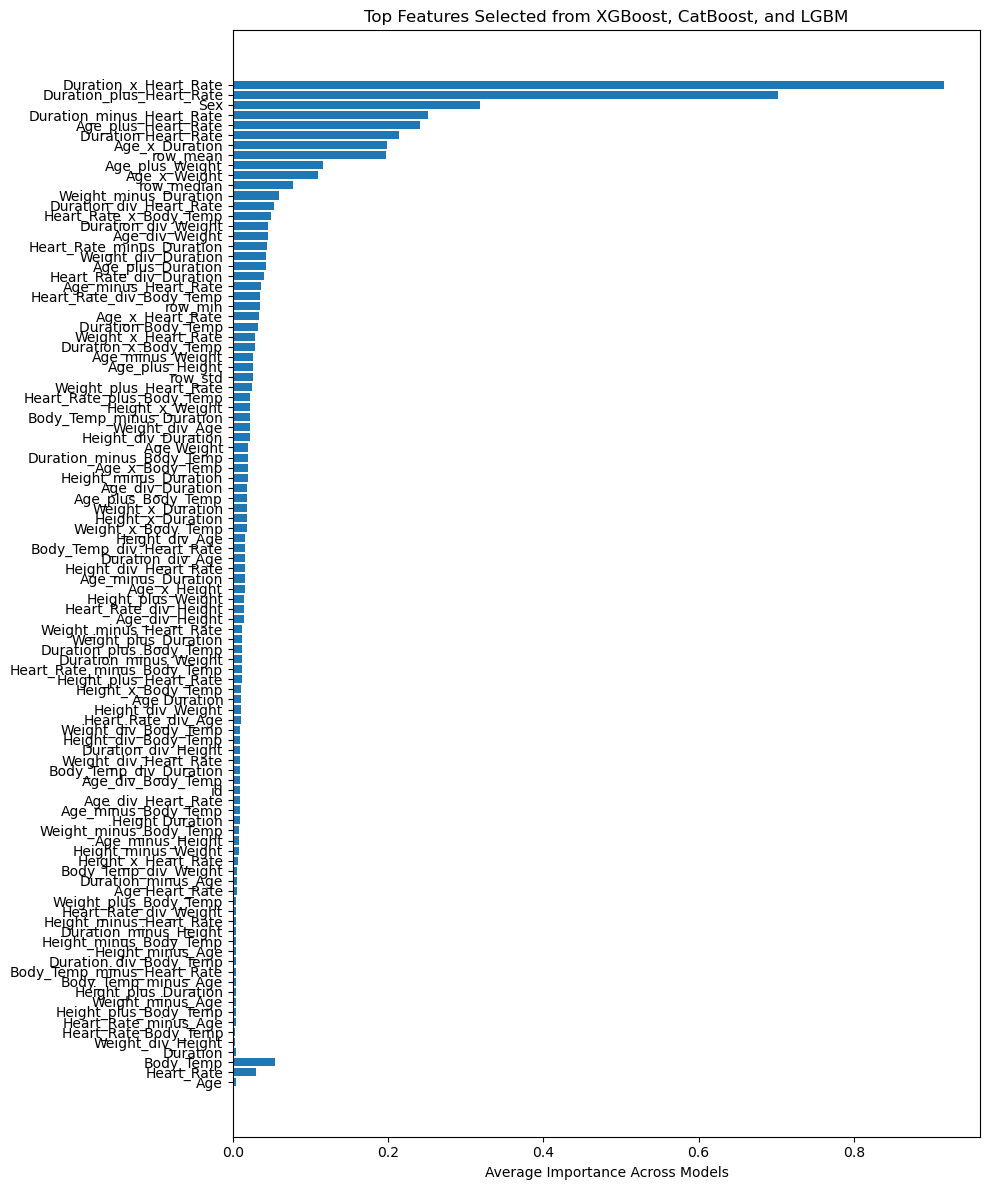

In [181]:
df_top = df[df['feature'].isin(top_features)].sort_values(by='avg_importance', ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(df_top['feature'], df_top['avg_importance'])
plt.xlabel("Average Importance Across Models")
plt.title("Top Features Selected from XGBoost, CatBoost, and LGBM")
plt.tight_layout()
plt.show()

In [182]:
X = X[top_features]

In [183]:
X.drop(columns=['id'], inplace=True)

In [184]:
y = np.log1p(train['Calories'])  
X_test = test.drop(columns=['id'])


FEATURES = X.columns.tolist()

In [185]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Columns: 103 entries, Duration_x_Heart_Rate to Weight_div_Height
dtypes: category(1), float64(101), int64(1)
memory usage: 584.4 MB


In [186]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time

FOLDS = 7
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=42)
models = {
    'CatBoost': CatBoostRegressor(verbose=100, random_seed=42, cat_features=['Sex'], early_stopping_rounds=100),
    'XGBoost': XGBRegressor(max_depth=10, colsample_bytree=0.7, subsample=0.9, n_estimators=2000, learning_rate=0.02,
                            gamma=0.01, max_delta_step=2, early_stopping_rounds=100, eval_metric='rmse',
                            enable_categorical=True, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=2000, learning_rate=0.02, max_depth=10, colsample_bytree=0.7,
                              subsample=0.9, random_state=42, verbose=-1)
}

results = {name: {'oof': np.zeros(len(train)), 'pred': np.zeros(len(test)), 'rmsle': []} for name in models}

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    for i, (train_idx, valid_idx) in enumerate(kf.split(X, y)):
        print(f"\nFold {i+1}")
        x_train, y_train = X.iloc[train_idx], y[train_idx]
        x_valid, y_valid = X.iloc[valid_idx], y[valid_idx]
        
        x_train = x_train.loc[:, ~x_train.columns.duplicated()]
        x_valid = x_valid.loc[:, ~x_valid.columns.duplicated()]
        x_test = X_test.loc[:, ~X_test.columns.duplicated()].copy()

        start = time.time()
        
        if name == 'XGBoost':
            model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=100)
        elif name == 'CatBoost':
            model.fit(x_train, y_train, eval_set=(x_valid, y_valid))
        else:
            model.fit(x_train, y_train)

        oof_pred = model.predict(x_valid)
        test_pred = model.predict(x_test)
        
        results[name]['oof'][valid_idx] = oof_pred
        results[name]['pred'] += test_pred / FOLDS
        
        rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_valid), np.expm1(oof_pred)))
        results[name]['rmsle'].append(rmsle)
        
        print(f"Fold {i+1} RMSLE: {rmsle:.4f}")
        print(f"Training time: {time.time() - start:.1f} sec")


print("\n=== Model Comparison ===")
for name in models:
    mean_rmsle = np.mean(results[name]['rmsle'])
    std_rmsle = np.std(results[name]['rmsle'])
    print(f"{name} - Mean RMSLE: {mean_rmsle:.4f} ± {std_rmsle:.4f}")


=== Training CatBoost ===

Fold 1
Learning rate set to 0.14053
0:	learn: 0.8364575	test: 0.8356998	best: 0.8356998 (0)	total: 43.9ms	remaining: 43.8s
100:	learn: 0.0629275	test: 0.0638866	best: 0.0638866 (100)	total: 3.42s	remaining: 30.4s
200:	learn: 0.0602706	test: 0.0619017	best: 0.0619017 (200)	total: 6.72s	remaining: 26.7s
300:	learn: 0.0589740	test: 0.0611819	best: 0.0611819 (300)	total: 10.1s	remaining: 23.5s
400:	learn: 0.0581559	test: 0.0607371	best: 0.0607371 (400)	total: 13.5s	remaining: 20.2s
500:	learn: 0.0575251	test: 0.0605384	best: 0.0605384 (500)	total: 16.8s	remaining: 16.8s
600:	learn: 0.0570151	test: 0.0603520	best: 0.0603520 (600)	total: 20.4s	remaining: 13.6s
700:	learn: 0.0565709	test: 0.0602446	best: 0.0602446 (700)	total: 23.9s	remaining: 10.2s
800:	learn: 0.0561774	test: 0.0601592	best: 0.0601561 (799)	total: 27.2s	remaining: 6.77s
900:	learn: 0.0558258	test: 0.0601078	best: 0.0601063 (899)	total: 30.6s	remaining: 3.36s
999:	learn: 0.0554917	test: 0.0600323	b

CatBoostError: features data: pandas.DataFrame column 'Sex' has dtype 'category' but is not in  cat_features list